In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score, f1_score, cohen_kappa_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, cohen_kappa_score, roc_curve, auc


from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Update the path to the location of the respective CSV file
#NOTE: This code was developed on google colab so this step might have to be fixed

from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Colab Notebooks/preprocessed_data.csv'

#Dataframe conversion
data = pd.read_csv(file_path, encoding='latin1')

# Define the target and features
X = data.drop(columns=['risk'])
y = data['risk']

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:


# Split Data Into Train & Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model for feature selection
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances and sort them
importances = rf_model.feature_importances_

# Select the top 15 feature indices based on importance
indices = importances.argsort()[-15:][::-1]

# Select the top 15 features based on these indices
X_train_selected = X_train.iloc[:, indices]
X_test_selected = X_test.iloc[:, indices]

# Print the top 15 selected features
selected_features = X_train.columns[indices]
print("\nTop 15 Selected Features:")
print(selected_features)


Top 15 Selected Features:
Index(['total_pymnt', 'out_prncp', 'int_rate', 'earliest_cr_line',
       'account_age', 'revol_bal', 'revol_util', 'dti', 'installment',
       'loan_amnt', 'annual_inc', 'total_acc', 'grade', 'open_acc',
       'verification_status'],
      dtype='object')


Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best Parameters for Random Forest:
max_depth = 20 max_features = sqrt

Fold 1:
  Accuracy: 0.912, Recall: 0.904, Precision: 0.919, F1 Score: 0.911, AUC: 0.974

Fold 2:
  Accuracy: 0.912, Recall: 0.906, Precision: 0.917, F1 Score: 0.911, AUC: 0.975

Fold 3:
  Accuracy: 0.911, Recall: 0.904, Precision: 0.918, F1 Score: 0.911, AUC: 0.975

Fold 4:
  Accuracy: 0.914, Recall: 0.909, Precision: 0.918, F1 Score: 0.913, AUC: 0.976

Fold 5:
  Accuracy: 0.915, Recall: 0.911, Precision: 0.918, F1 Score: 0.915, AUC: 0.976

Final Model Performance After Hyperparameter Tuning:
Accuracy: 0.913
Recall: 0.907
Precision: 0.918
F1 Score: 0.912
Kappa Score: 0.826
Average AUC: 0.975


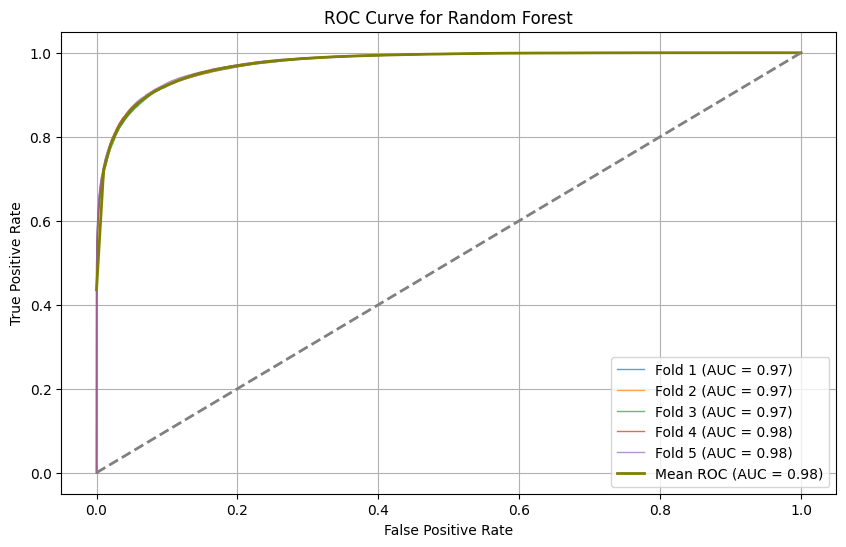

In [ ]:


# Apply SMOTE only on the Training Set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_selected, y_train)

# Grid Search for Best Hyperparameters for Random Forest
param_grid = {
    'max_depth': [10, 20],  # Depth of each tree
    'max_features': ['sqrt', 'log2'],  # Features to consider for splitting nodes
}

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Perform Grid Search
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train_resampled, y_train_resampled)

# Get best parameters and model
best_max_depth = grid_search.best_params_['max_depth']
best_max_features = grid_search.best_params_['max_features']
best_model = grid_search.best_estimator_

print(f"\nBest Parameters for Random Forest:")
print(f"max_depth = {best_max_depth} "
      f"max_features = {best_max_features}")

# Evaluate on K-Fold Cross-Validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies, recalls, precisions, f1_scores, kappas, roc_aucs = [], [], [], [], [], []

# Initialize plot data
fpr_all, tpr_all, auc_all = [], [], []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_resampled, y_train_resampled), start=1):
    print(f"\nFold {fold}:")

    # Create Fold-Specific Train/Validation Split
    X_train_fold, X_val_fold = X_train_resampled.iloc[train_idx], X_train_resampled.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_resampled.iloc[train_idx], y_train_resampled.iloc[val_idx]

    # Train Best Model with Optimized Hyperparameters
    best_model.fit(X_train_fold, y_train_fold)

    # Make Predictions
    y_pred = best_model.predict(X_val_fold)
    y_pred_proba = best_model.predict_proba(X_val_fold)[:, 1]  # Probabilities for the positive class

    # Compute Metrics
    accuracy = accuracy_score(y_val_fold, y_pred)
    recall = recall_score(y_val_fold, y_pred, average='binary')
    precision = precision_score(y_val_fold, y_pred, average='binary')
    f1 = f1_score(y_val_fold, y_pred, average='binary')
    kappa = cohen_kappa_score(y_val_fold, y_pred)

    # Compute ROC Curve
    fpr, tpr, thresholds = roc_curve(y_val_fold, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Store Metrics
    accuracies.append(accuracy)
    recalls.append(recall)
    precisions.append(precision)
    f1_scores.append(f1)
    kappas.append(kappa)
    roc_aucs.append(roc_auc)

    # Store ROC curve data for plotting later
    fpr_all.append(fpr)
    tpr_all.append(tpr)
    auc_all.append(roc_auc)

    print(f"  Accuracy: {accuracy:.3f}, Recall: {recall:.3f}, Precision: {precision:.3f}, F1 Score: {f1:.3f}, AUC: {roc_auc:.3f}")

# Print Final Performance Metrics
print("\nFinal Model Performance After Hyperparameter Tuning:")
print(f"Accuracy: {np.mean(accuracies):.3f}")
print(f"Recall: {np.mean(recalls):.3f}")
print(f"Precision: {np.mean(precisions):.3f}")
print(f"F1 Score: {np.mean(f1_scores):.3f}")
print(f"Kappa Score: {np.mean(kappas):.3f}")
print(f"Average AUC: {np.mean(roc_aucs):.3f}")

# Plot the ROC Curve for the average performance
plt.figure(figsize=(10, 6))

# Plot the ROC curve for each fold
for i in range(len(fpr_all)):
    plt.plot(fpr_all[i], tpr_all[i], lw=1, alpha=0.7, label=f'Fold {i+1} (AUC = {auc_all[i]:.2f})')

# Plot the average ROC curve
mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.mean([np.interp(mean_fpr, fpr_all[i], tpr_all[i]) for i in range(len(fpr_all))], axis=0)
mean_auc = np.mean(roc_aucs)
plt.plot(mean_fpr, mean_tpr, color='olive', label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2)

# Plot diagonal (no skill)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=2)

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

